In [1]:
import os, torch

print("GPU disponible :", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

print("Dossier de travail :", os.getcwd())
print("train.csv présent :", os.path.exists("train.csv"), "| test.csv présent :", os.path.exists("test.csv"))

GPU disponible : True
Tesla T4
Dossier de travail : /content
train.csv présent : False | test.csv présent : False


In [3]:
!pip install transformers

In [5]:
import shutil
shutil.move("/train.csv", "/content/train.csv")
shutil.move("/test.csv", "/content/test.csv")

'/content/test.csv'

In [6]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

torch.manual_seed(42)
np.random.seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

train = pd.read_csv("train.csv").dropna()
test = pd.read_csv("test.csv").dropna()

N_TRAIN = 10000   # nombre d'emails d'entraînement (maximum : 23812)
MAX_LEN = 128     # longueur maximale en tokens
EPOCHS = 2

echantillon = train.sample(N_TRAIN, random_state=42)
tr, va = train_test_split(echantillon, test_size=0.1, random_state=42, stratify=echantillon["label"])
print("Entraînement :", len(tr), "| Validation :", len(va), "| Test :", len(test))

Entraînement : 9000 | Validation : 1000 | Test : 5954


In [7]:
MODEL = "distilbert-base-uncased"
tok = AutoTokenizer.from_pretrained(MODEL)

def encoder(textes):
    enc = tok(list(textes), truncation=True, padding="max_length",
              max_length=MAX_LEN, return_tensors="pt")
    return enc["input_ids"], enc["attention_mask"]

ids_tr, mask_tr = encoder(tr["text_clean"])
ids_va, mask_va = encoder(va["text_clean"])
ids_te, mask_te = encoder(test["text_clean"])

y_tr = torch.tensor(tr["label"].values)
y_va = torch.tensor(va["label"].values)

exemple = tr["text_clean"].iloc[0]
print("Email :", exemple[:150], "...")
print("Tokens :", tok.tokenize(exemple)[:20])

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Email : eastrans nomination change effective nombre nombre nombre deliveries eastrans continue nombre nombre mmbtu dy redeliveries nombre fuels cotton valley  ...
Tokens : ['east', '##ran', '##s', 'nomination', 'change', 'effective', 'no', '##mbre', 'no', '##mbre', 'no', '##mbre', 'deliveries', 'east', '##ran', '##s', 'continue', 'no', '##mbre', 'no']


In [8]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=2).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

train_dl = DataLoader(TensorDataset(ids_tr, mask_tr, y_tr), batch_size=32, shuffle=True)
val_dl = DataLoader(TensorDataset(ids_va, mask_va, y_va), batch_size=64)

print("Nombre de paramètres :", f"{sum(p.numel() for p in model.parameters()):,}")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Nombre de paramètres : 66,955,010


In [10]:
def evaluer_val(dl):
    model.eval()
    perte, bons, total = 0.0, 0, 0
    with torch.no_grad():
        for ids, mask, y in dl:
            ids, mask, y = ids.to(device), mask.to(device), y.to(device)
            out = model(input_ids=ids, attention_mask=mask, labels=y)
            perte += out.loss.item() * len(y)
            bons += (out.logits.argmax(-1) == y).sum().item()
            total += len(y)
    return perte / total, bons / total

pertes_batch = []
historique = {"epoque": [], "val_perte": [], "val_acc": []}

debut = time.time()
for epoque in range(EPOCHS):
    model.train()
    for ids, mask, y in train_dl:
        ids, mask, y = ids.to(device), mask.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(input_ids=ids, attention_mask=mask, labels=y)  # cross-entropy
        out.loss.backward()
        optimizer.step()
        pertes_batch.append(out.loss.item())

    val_perte, val_acc = evaluer_val(val_dl)
    historique["epoque"].append(epoque + 1)
    historique["val_perte"].append(val_perte)
    historique["val_acc"].append(val_acc)
    print(f"Époque {epoque+1}/{EPOCHS} | perte validation : {val_perte:.4f} | accuracy validation : {val_acc:.4f}")

temps_bert = time.time() - debut
print(f"\nTemps d'entraînement : {temps_bert:.1f} s")

Époque 1/2 | perte validation : 0.0317 | accuracy validation : 0.9880
Époque 2/2 | perte validation : 0.0312 | accuracy validation : 0.9900

Temps d'entraînement : 205.8 s


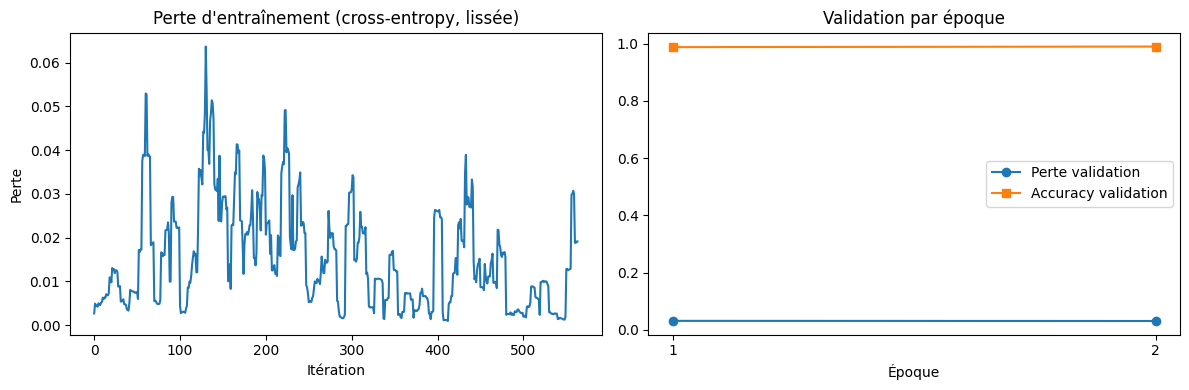

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

lisse = pd.Series(pertes_batch).rolling(10, min_periods=1).mean()
ax[0].plot(lisse)
ax[0].set_title("Perte d'entraînement (cross-entropy, lissée)")
ax[0].set_xlabel("Itération")
ax[0].set_ylabel("Perte")

ax[1].plot(historique["epoque"], historique["val_perte"], marker="o", label="Perte validation")
ax[1].plot(historique["epoque"], historique["val_acc"], marker="s", label="Accuracy validation")
ax[1].set_title("Validation par époque")
ax[1].set_xlabel("Époque")
ax[1].set_xticks(historique["epoque"])
ax[1].legend()

plt.tight_layout()
plt.savefig("07b_courbes_apprentissage.png", dpi=150)
plt.show()

In [12]:
def predire(ids, mask, bs=128):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(ids), bs):
            out = model(input_ids=ids[i:i+bs].to(device), attention_mask=mask[i:i+bs].to(device))
            preds.append(out.logits.argmax(-1).cpu())
    return torch.cat(preds).numpy()

y_test = test["label"].values
y_pred = predire(ids_te, mask_te)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rap = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy  : {acc:.4f}")
print(f"Précision : {prec:.4f}")
print(f"Rappel    : {rap:.4f}")
print(f"F1-score  : {f1:.4f}\n")
print(classification_report(y_test, y_pred, target_names=["Non-spam", "Spam"], digits=4))

Accuracy  : 0.9869
Précision : 0.9860
Rappel    : 0.9860
F1-score  : 0.9860

              precision    recall  f1-score   support

    Non-spam     0.9877    0.9877    0.9877      3159
        Spam     0.9860    0.9860    0.9860      2795

    accuracy                         0.9869      5954
   macro avg     0.9869    0.9869    0.9869      5954
weighted avg     0.9869    0.9869    0.9869      5954



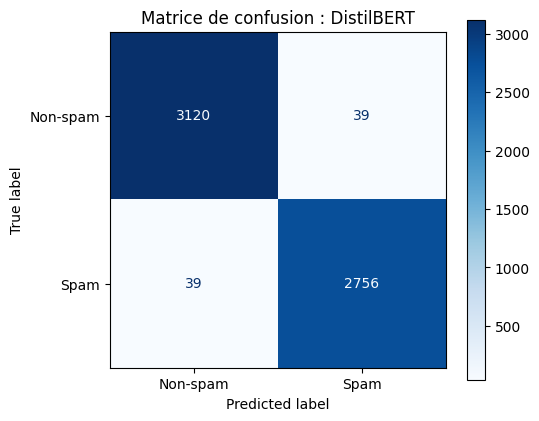

Faux positifs : 39 | Faux négatifs : 39


In [13]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=["Non-spam", "Spam"]).plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Matrice de confusion : DistilBERT")
ax.grid(False)
plt.tight_layout()
plt.savefig("07b_matrice_confusion_bert.png", dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Faux positifs : {fp} | Faux négatifs : {fn}")

In [16]:
resultat = pd.DataFrame([{
    "modèle": f"DistilBERT ({N_TRAIN} emails, {EPOCHS} époques)",
    "accuracy": acc, "précision": prec, "rappel": rap, "f1": f1,
    "faux_positifs": int(fp), "faux_négatifs": int(fn),
    "f1_validation_croisée": np.nan,
    "temps_entraînement_s": round(temps_bert, 1),
}])
resultat.to_csv("resultat_bert.csv", index=False)

pd.DataFrame({"y_true": y_test, "y_pred": y_pred, "text_clean": test["text_clean"].values}
             ).to_csv("predictions_bert.csv", index=False)

from google.colab import files
for f in ["resultat_bert.csv", "predictions_bert.csv",
          "07b_courbes_apprentissage.png", "07b_matrice_confusion_bert.png"]:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>